In [1]:
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

import optuna
from sklearn.svm import LinearSVC

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [3]:
# ==========================================
# BLOQUE 1: PREPARACIÓN GLOBAL Y ESCALADO (VITAL PARA SVM)
# ==========================================
# 1. Forzamos la conversión a matriz plana
X_train_np = np.array(X_full_train_np)
y_train_np = np.array(y_full_train)

# 2. Etiquetas 0/1
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)

# 3. El escalado se hará dentro de cada fold para evitar data leakage
print("Preparando el SVM con escalado por fold...")

# ==========================================
# BLOQUE 2: FUNCIÓN OBJECTIVE
# ==========================================
def objective(trial):
    
    # 2.1 Espacio de búsqueda para LinearSVC
    # El parámetro C suele buscarse en escala logarítmica (de muy pequeño a muy grande)
    C_val = trial.suggest_float("C", 1e-4, 1e2, log=True)
    
    # 2.2 Configuración CV (3 Folds)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    latencies = [] 

    # 2.3 Bucle de Entrenamiento y Medición
    for train_idx, val_idx in skf.split(X_train_np, y_train_01):
        X_train_cv_raw, X_val_cv_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_train_cv, y_val_cv = y_train_01[train_idx], y_train_01[val_idx]

        scaler = StandardScaler()
        X_train_cv = scaler.fit_transform(X_train_cv_raw)
        X_val_cv = scaler.transform(X_val_cv_raw)

        # dual=False es un truco de optimización brutal cuando tienes 
        # más filas (paquetes) que columnas (features)
        model = LinearSVC(
            C=C_val,
            dual=False, 
            random_state=42,
            max_iter=2000 # Le damos margen para converger
        )

        model.fit(X_train_cv, y_train_cv)

        # 1. Predecir y guardar Eficacia (F1)
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))
        
        # 2. Medir Eficiencia (Latencia)
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        
        _ = model.predict(X_lat[:500]) # Warm-up
        
        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)
            
        latencies.append(float(np.mean(rep_lat)))

    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies))
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# ==========================================
# BLOQUE 3: EJECUCIÓN DEL ESTUDIO
# ==========================================
study = optuna.create_study(directions=["maximize", "minimize"], study_name="linearsvc_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con LinearSVC (CPU)...")

study.optimize(objective, n_trials=50) 

# ==========================================
# BLOQUE 4: EXTRACCIÓN Y PARETO
# ==========================================
pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "C": t.params["C"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("linearsvc_ton_trials_results_cv.csv")

print("\n✅ Resultados guardados en 'linearsvc_ton_trials_results_cv.csv'")

[I 2026-05-02 11:15:22,141] A new study created in memory with name: linearsvc_ids_optimization


Preparando el SVM con escalado por fold...
🚀 Iniciando barrido multiobjetivo con LinearSVC (CPU)...


[I 2026-05-02 11:15:23,248] Trial 0 finished with values: [0.8955964596542408, 2.63008673209697e-05] and parameters: {'C': 0.00871618419549162}.
[I 2026-05-02 11:15:51,584] Trial 1 finished with values: [0.8956314154609939, 2.725508296862245e-05] and parameters: {'C': 0.6169393791396656}.
[I 2026-05-02 11:15:52,732] Trial 2 finished with values: [0.8955174340058857, 2.5693597272038457e-05] and parameters: {'C': 0.005218590240412382}.
[I 2026-05-02 11:15:53,646] Trial 3 finished with values: [0.8953614769944748, 2.5948459903399153e-05] and parameters: {'C': 0.0017649386977414657}.
[I 2026-05-02 11:16:33,053] Trial 4 finished with values: [0.8956130468120342, 2.5938880474617082e-05] and parameters: {'C': 0.9778918096110671}.
[I 2026-05-02 11:16:34,942] Trial 5 finished with values: [0.8956038285331923, 2.5871122488752007e-05] and parameters: {'C': 0.024697097734148122}.
[I 2026-05-02 11:16:52,129] Trial 6 finished with values: [0.8956093587419768, 2.677865792065859e-05] and parameters: {


✅ Resultados guardados en 'linearsvc_ton_trials_results_cv.csv'


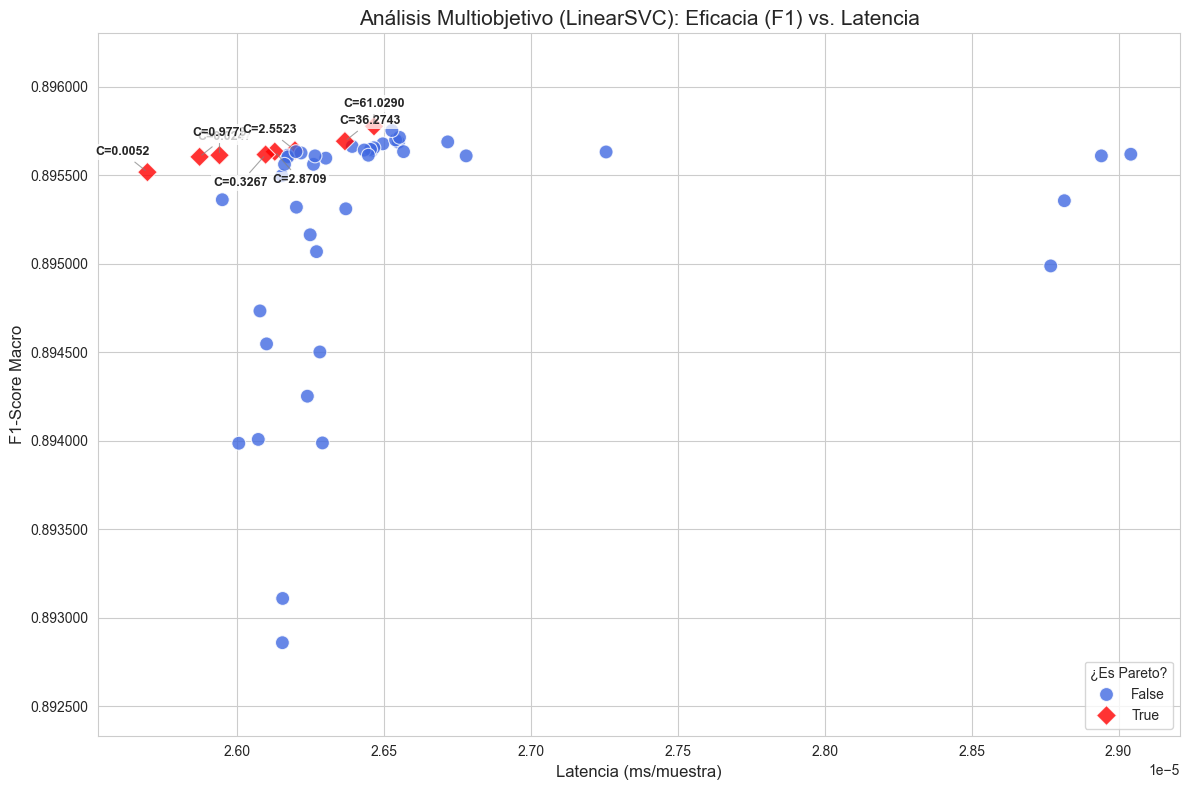

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

df_svm = pl.read_csv("linearsvc_ton_trials_results_cv.csv")
pareto_points = df_svm.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = plt.gca()

sns.scatterplot(
    x=df_svm["latency_ms"].to_numpy(),
    y=df_svm["f1_macro"].to_numpy(),
    hue=df_svm["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df_svm["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8,
    ax=ax
)

# Ajustamos el eje Y para que las etiquetas no se disparen fuera de la figura
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))
y_vals = df_svm["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.18, 0.00003)
    ax.set_ylim(y_min - margin, y_max + margin)

# Anotamos solo los puntos Pareto con pequeños desplazamientos alternos
offsets = [(-18, 10), (18, 10), (0, 12), (-18, -16), (18, -16)]
for i, row in enumerate(pareto_points.iter_rows(named=True)):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        f"C={row['C']:.4f}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='center',
        va='bottom' if dy >= 0 else 'top',
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.7)
    )

plt.title("Análisis Multiobjetivo (LinearSVC): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?", loc="lower right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3948228/32411818.py:49: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


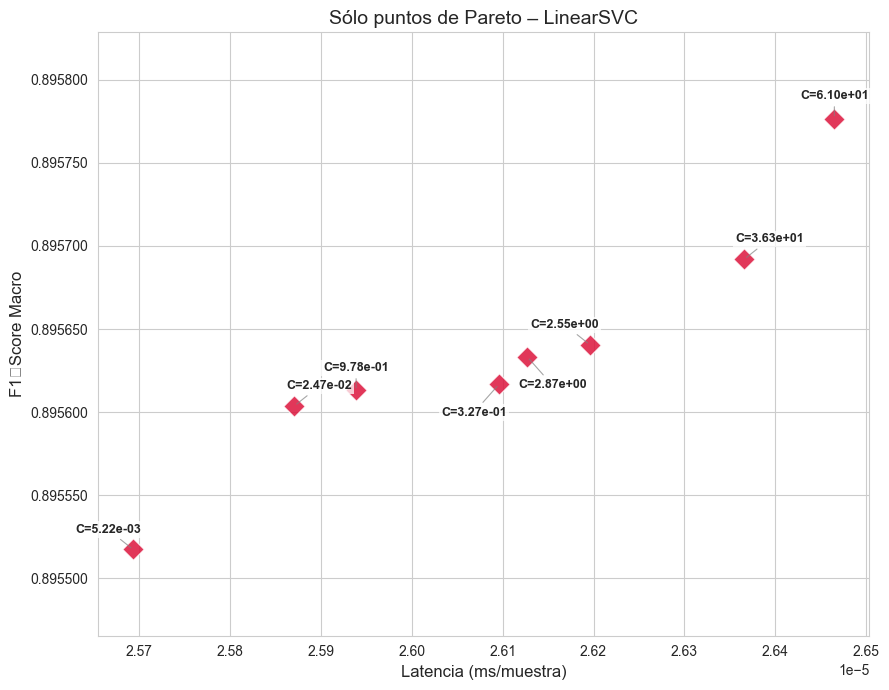

Puntos en la frontera de Pareto:


C,f1_macro,f1_std,latency_ms,is_pareto
f64,f64,f64,f64,bool
0.005219,0.895517,0.00119,0.000026,true
0.024697,0.895604,0.001177,0.000026,true
0.977892,0.895613,0.001156,0.000026,true
0.326653,0.895617,0.001163,0.000026,true
2.870875,0.895633,0.001166,0.000026,true
2.552291,0.895641,0.001165,0.000026,true
36.274336,0.895692,0.001162,0.000026,true
61.028994,0.895777,0.001123,0.000026,true


In [5]:
# filtramos únicamente los ensayos marcados como Pareto
pareto_df = df_svm.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(9, 7))
sns.set_style("whitegrid")
ax = plt.gca()

# un único scatter con los puntos de Pareto
sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    s=120,
    marker="D",
    color="crimson",
    alpha=0.85,
    ax=ax
)

# Ajustamos el eje Y para evitar el formato raro y dejar margen a las etiquetas
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))
y_vals = pareto_df["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00003)
    ax.set_ylim(y_min - margin, y_max + margin)

# Anotamos el valor de C pegado a cada marca roja
offsets = [(-18, 10), (18, 10), (0, 12), (-18, -16), (18, -16)]
for i, row in enumerate(pareto_df.iter_rows(named=True)):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        f"C={row['C']:.2e}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9,
        ha='center',
        va='bottom' if dy >= 0 else 'top',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.7)
    )

plt.title("Sólo puntos de Pareto – LinearSVC", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1‑Score Macro", fontsize=12)
plt.tight_layout()
plt.show()

# ahora que ya hemos generado el gráfico, veamos en bruto qué ensayos
# componen la frontera de Pareto y cuáles son sus valores

print("Puntos en la frontera de Pareto:")
display(pareto_df)

In [6]:
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Convertimos las etiquetas de -1/1 a 0/1 para que las métricas funcionen igual
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

# Aseguramos que el Test sea un array de NumPy
X_test_np_arr = np.array(X_test_np)

# ==========================================
# EVALUACIÓN FINAL EN TEST (3 CANDIDATOS SVM LINEAL)
# ==========================================

candidatos_svm = [
    {"C": 0.024697, "nombre": "Candidato 1"},
    {"C": 0.977892, "nombre": "Candidato 2"},
    {"C": 0.326653, "nombre": "Candidato 3"},
    {"C": 2.870875, "nombre": "Candidato 4"},
    {"C": 2.552291, "nombre": "Candidato 5"},
    {"C": 36.274336, "nombre": "Candidato 6"},
]

resultados_svm_test = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (Linear SVM) ---\n")

# 1. ESCALADO DE DATOS (El paso crítico)
print("Escalando datos (fit en Train, transform en Test)...")
scaler = StandardScaler()
# El scaler aprende las medias del Train y lo transforma
X_train_scaled = scaler.fit_transform(X_train_np)
# Al Test SOLO se le aplica la transformación matemática, sin aprender de él
X_test_scaled = scaler.transform(X_test_np_arr) 

# 2. BUCLE DE EVALUACIÓN
for c in candidatos_svm:
    print(f"Probando: {c['nombre']} (C={c['C']:.6f})...")
    
    # Inicializamos modelo
    model = LinearSVC(
        C=c["C"],
        dual=False,
        random_state=42,
        max_iter=2000
    )
    
    # Entrenamos con el 100% del Train escalado
    model.fit(X_train_scaled, y_train_01)
    
    # Warm-up para despertar la caché de la CPU
    _ = model.predict(X_test_scaled[:min(1000, len(X_test_scaled))])
    
    # Medición real de latencia en el Set de Test
    t0 = time.perf_counter()
    y_pred01 = model.predict(X_test_scaled)
    t1 = time.perf_counter()
    
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000
    
    f1_test = f1_score(y_test_np01, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_np01, y_pred01)
    
    resultados_svm_test.append({
        "Perfil": c["nombre"],
        "C": c["C"],
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

# 3. MOSTRAR TABLA
df_final_svm = pl.DataFrame(resultados_svm_test)
print("\n" + "="*70)
print("              TABLA COMPARATIVA FINAL TEST (Linear SVM)")
print("="*70)
print(df_final_svm)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (Linear SVM) ---

Escalando datos (fit en Train, transform en Test)...
Probando: Candidato 1 (C=0.024697)...
Probando: Candidato 2 (C=0.977892)...
Probando: Candidato 3 (C=0.326653)...
Probando: Candidato 4 (C=2.870875)...
Probando: Candidato 5 (C=2.552291)...
Probando: Candidato 6 (C=36.274336)...

              TABLA COMPARATIVA FINAL TEST (Linear SVM)
shape: (6, 5)
┌─────────────┬───────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ C         ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---       ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ f64       ┆ f64      ┆ f64           ┆ f64         │
╞═════════════╪═══════════╪══════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 0.024697  ┆ 0.897624 ┆ 0.926603      ┆ 0.000027    │
│ Candidato 2 ┆ 0.977892  ┆ 0.897712 ┆ 0.926674      ┆ 0.000051    │
│ Candidato 3 ┆ 0.326653  ┆ 0.897712 ┆ 0.926674      ┆ 0.000029    │
│ Candidato 4 ┆ 2.870875  ┆ 0.89781